# Hospital Readmission Prediction — Exploratory Data Analysis

## Project Overview
This project predicts whether a diabetic patient will be readmitted to hospital 
within 30 days of discharge. Early identification of high-risk patients could 
allow clinical teams to intervene and reduce unnecessary readmissions.

**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Source:** UCI Machine Learning Repository via Kaggle  
**Records:** 101,766 patient encounters | **Features:** 50 columns

---

In [7]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap', 'streamlit', 'imbalanced-learn', 'seaborn'])

CompletedProcess(args=['pip', 'install', 'xgboost', 'shap', 'streamlit', 'imbalanced-learn', 'seaborn'], returncode=0)

## 1. Loading & Initial Inspection
Loading the dataset and performing a first look at shape, columns, and data types.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data - using full path
df = pd.read_csv(r'C:\Users\munta\Documents\hospital-readmission-project\data\diabetic_data.csv')
ids = pd.read_csv(r'C:\Users\munta\Documents\hospital-readmission-project\data\IDs_mapping.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (101766, 50)

Column names:
 ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Missing Value Analysis
This dataset uses `?` instead of NaN for missing values. We check both standard 
NaN and `?` occurrences across all columns.

In [11]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
print("Missing values (NaN):")
print(missing_percent[missing_percent > 0])

# Check for ? values (this dataset uses ? for missing)
print("\nColumns with '?' values:")
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"{col}: {count} ({round(count/len(df)*100, 1)}%)")

Missing values (NaN):
max_glu_serum    94.746772
A1Cresult        83.277322
dtype: float64

Columns with '?' values:
race: 2273 (2.2%)
weight: 98569 (96.9%)
payer_code: 40256 (39.6%)
medical_specialty: 49949 (49.1%)
diag_1: 21 (0.0%)
diag_2: 358 (0.4%)
diag_3: 1423 (1.4%)


## 3. Target Variable Distribution
Our target is `readmitted` — we convert this to a binary classification problem:
- **1** = Readmitted within 30 days (the positive class we want to predict)
- **0** = Not readmitted within 30 days

This focuses the problem on clinically urgent cases.

In [12]:
# Check your target variable distribution
print(df['readmitted'].value_counts())
print("\nPercentages:")
print(df['readmitted'].value_counts(normalize=True) * 100)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentages:
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


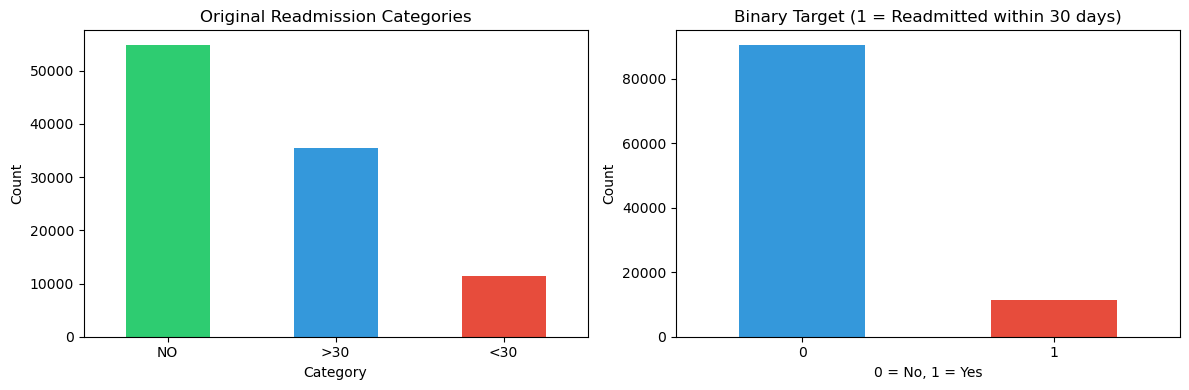


Class imbalance ratio: 90409 vs 11357


In [13]:
# Create binary target variable
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

# Visualise it
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original 3 classes
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Original Readmission Categories')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Binary target
df['readmitted_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Binary Target (1 = Readmitted within 30 days)')
axes[1].set_xlabel('0 = No, 1 = Yes')
axes[1].set_ylabel('Count')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.savefig('readmission_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {df['readmitted_binary'].value_counts()[0]} vs {df['readmitted_binary'].value_counts()[1]}")

### Observation
There is a significant class imbalance — only **11.2%** of patients are readmitted 
within 30 days (11,357 vs 90,409). This means a naive model that always predicts 
"not readmitted" would achieve 88% accuracy while being clinically useless.

We will address this using **SMOTE** (Synthetic Minority Oversampling Technique) 
during modelling.

## 4. Feature Distributions vs Readmission
Exploring how key numerical features differ between readmitted and non-readmitted 
patients. Box plots show the median, interquartile range, and outliers for each group.

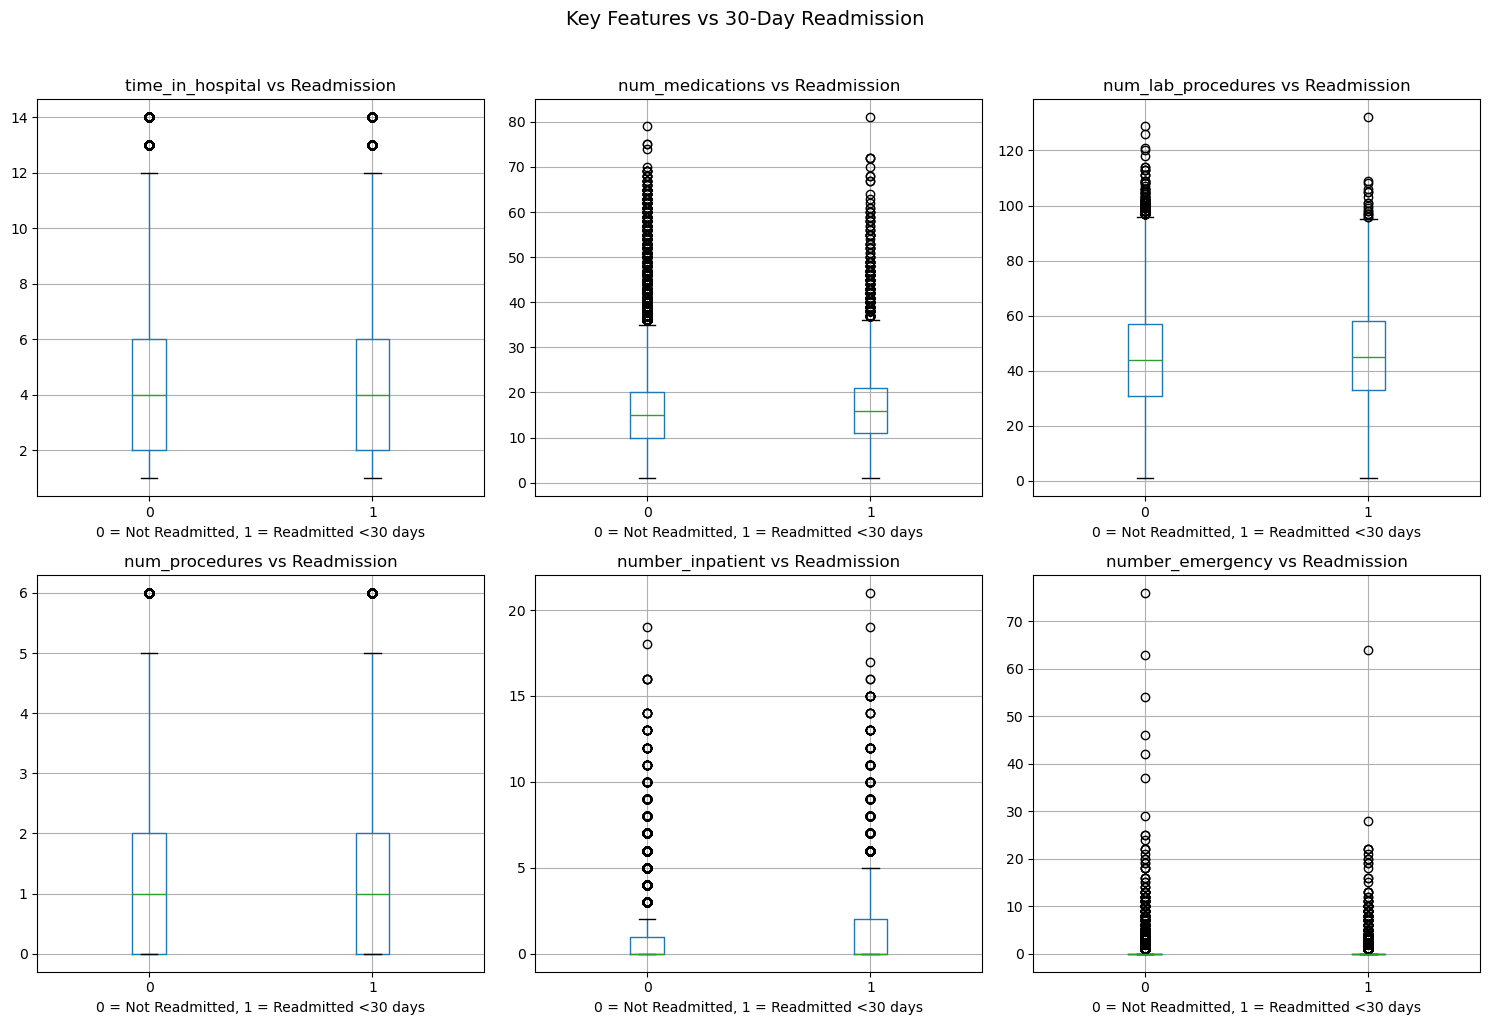

In [15]:
# Explore key numerical features vs readmission
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

numerical_features = ['time_in_hospital', 'num_medications', 
                       'num_lab_procedures', 'num_procedures',
                       'number_inpatient', 'number_emergency']

for i, feature in enumerate(numerical_features):
    ax = axes[i//3][i%3]
    df.boxplot(column=feature, by='readmitted_binary', ax=ax)
    ax.set_title(f'{feature} vs Readmission')
    ax.set_xlabel('0 = Not Readmitted, 1 = Readmitted <30 days')

plt.suptitle('Key Features vs 30-Day Readmission', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations
- **number_inpatient** shows the clearest separation between groups — patients 
  readmitted within 30 days have a higher median number of prior inpatient visits, 
  suggesting illness severity is a key factor
- **time_in_hospital** and **num_medications** show minimal difference between 
  groups, indicating they will be weak standalone predictors
- **number_emergency** has many outliers in both groups, suggesting high variance 
  that may reduce its predictive value
- All features show considerable overlap, confirming this is a difficult 
  classification problem — consistent with published benchmarks on this dataset